In [1]:
from glob import glob
import os
import pandas as pd

In [2]:
path_list = glob("./mnist-pngs/**/*.png", recursive=True)

In [3]:
path_frame = pd.DataFrame({
    "path" : path_list
})

In [4]:
path_frame["type"] = path_frame["path"].apply(lambda x: x.split("/")[-3])
path_frame["label"] = path_frame["path"].apply(lambda x: x.split("/")[-2])

In [5]:
path_frame

,path,type,label
0,./mnist-pngs/test/9/66710.png,test,9
1,./mnist-pngs/test/9/69423.png,test,9
2,./mnist-pngs/test/9/65219.png,test,9
3,./mnist-pngs/test/9/67426.png,test,9
4,./mnist-pngs/test/9/69386.png,test,9
...,...,...,...
69995,./mnist-pngs/train/5/31651.png,train,5
69996,./mnist-pngs/train/5/437.png,train,5
69997,./mnist-pngs/train/5/33734.png,train,5
69998,./mnist-pngs/train/5/40902.png,train,5


In [6]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

In [9]:
train_frame = path_frame[path_frame["type"]=="train"]
display(train_frame)
train_data = [np.array(Image.open(item)) for item in train_frame["path"].head(1000)]
xTrain = np.array(train_data)
xTrain = xTrain / 255

,path,type,label
10000,./mnist-pngs/train/9/36655.png,train,9
10001,./mnist-pngs/train/9/32433.png,train,9
10002,./mnist-pngs/train/9/28319.png,train,9
10003,./mnist-pngs/train/9/4968.png,train,9
10004,./mnist-pngs/train/9/23502.png,train,9
...,...,...,...
69995,./mnist-pngs/train/5/31651.png,train,5
69996,./mnist-pngs/train/5/437.png,train,5
69997,./mnist-pngs/train/5/33734.png,train,5
69998,./mnist-pngs/train/5/40902.png,train,5


In [10]:
xTrain.shape

(1000, 28, 28)

In [17]:
xTrain = np.reshape(xTrain, (xTrain.shape[0], xTrain.shape[1]*xTrain.shape[2]))

In [18]:
xTrain.shape

(1000, 784)

In [19]:
import tensorflow as tf
from tensorflow.keras import layers

2025-07-16 21:39:18.977911: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [21]:
input_layer = tf.keras.Input(shape= xTrain.shape[1:])

encoder = layers.Dense(32, activation='elu')(input_layer)
encoder = layers.Dropout(0.25)(encoder)
encoder = layers.Dense(16, activation='elu')(encoder)
encoder = layers.Dropout(0.25)(encoder)
encoder = layers.Dense(8, activation='elu')(encoder)

decoder = layers.Dense(16, activation='elu')(encoder)
decoder = layers.Dropout(0.2)(decoder)
decoder = layers.Dense(32, activation='elu')(decoder)
decoder = layers.Dropout(0.2)(decoder)
decoder = layers.Dense(xTrain.shape[1], activation="sigmoid")(decoder)

autoencoder = tf.keras.Model(input_layer, decoder)
autoencoder.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │        25,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 784)            │        25,872 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,344 (204.47 KB)

 Trainable params: 52,344 (204.47 KB)

 Non-trainable params: 0 (0.00 B)

In [22]:
autoencoder.compile(optimizer="adam", loss="binary_crossentropy")

In [32]:
autoencoder.fit(xTrain, xTrain, epochs=50, batch_size=512)

Epoch 1/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2097
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2085
Epoch 3/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.2096
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.2068
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2104
Epoch 6/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2080
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2063
Epoch 8/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.2073
Epoch 9/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.2059
Epoch 10/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2077
Epoch 11/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.2062
Epoch 12/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.2064
Epoch 13/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2060
Epoch 14/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.2061
Epoch 15/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.2059
Epoch 16/50
2/2 ━━━━━━━━━━━━━━━━━━

In [33]:
y_pred = autoencoder.predict(xTrain)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 999us/step


In [34]:
y_pred

array([[2.6947038e-07, 7.8373450e-09, 1.6665210e-08, ..., 3.5563804e-08,
        2.3245237e-08, 3.7827952e-08],
       [2.3038589e-05, 2.3115774e-06, 4.0244677e-06, ..., 5.7810043e-06,
        4.0361601e-06, 5.6929907e-06],
       [1.4018810e-05, 1.2620651e-06, 2.1863402e-06, ..., 3.3369636e-06,
        2.3072057e-06, 3.3752713e-06],
       ...,
       [5.4404100e-06, 3.7415529e-07, 6.7779899e-07, ..., 1.1264839e-06,
        7.6845856e-07, 1.1589594e-06],
       [1.4329943e-07, 3.4744523e-09, 7.6349114e-09, ..., 1.7203142e-08,
        1.1141216e-08, 1.8453109e-08],
       [1.9834032e-03, 6.6561799e-04, 9.2611613e-04, ..., 9.5631077e-04,
        7.0495432e-04, 8.9378626e-04]], dtype=float32)

In [35]:
ae_in = np.reshape(xTrain, (1000, 28, 28))
ae_out = np.reshape(y_pred, (1000, 28, 28))

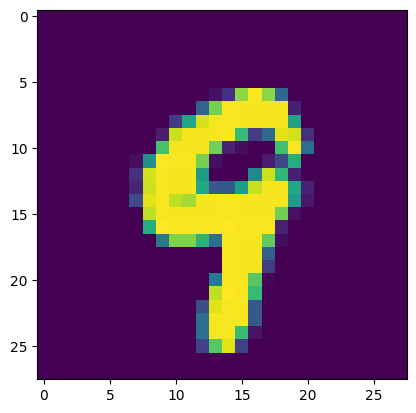

In [36]:
plt.imshow(ae_in[0])

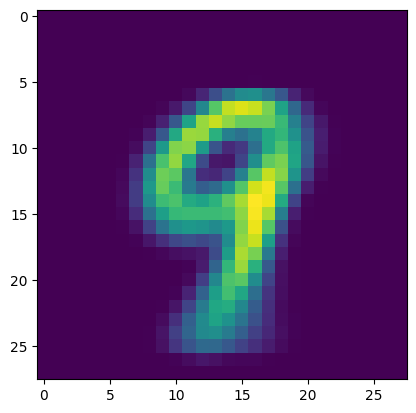

In [37]:
plt.imshow(ae_out[0])

In [39]:
autoencoder.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │        25,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 784)            │        25,872 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 157,034 (613.42 KB)

 Trainable params: 52,344 (204.47 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 104,690 (408.95 KB)

In [40]:
autoencoder.layers

[<InputLayer name=input_layer_1, built=True>,
 <Dense name=dense_6, built=True>,
 <Dropout name=dropout_4, built=True>,
 <Dense name=dense_7, built=True>,
 <Dropout name=dropout_5, built=True>,
 <Dense name=dense_8, built=True>,
 <Dense name=dense_9, built=True>,
 <Dropout name=dropout_6, built=True>,
 <Dense name=dense_10, built=True>,
 <Dropout name=dropout_7, built=True>,
 <Dense name=dense_11, built=True>]

In [41]:
autoencoder.input

<KerasTensor shape=(None, 784), dtype=float32, sparse=False, name=keras_tensor_11>

In [43]:
autoencoder.layers[5].output

<KerasTensor shape=(None, 8), dtype=float32, sparse=False, name=keras_tensor_16>

In [44]:
encoder_model = tf.keras.Model(autoencoder.input, autoencoder.layers[5].output)

In [46]:
encoder_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │        25,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 8)              │           136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,784 (100.72 KB)

 Trainable params: 25,784 (100.72 KB)

 Non-trainable params: 0 (0.00 B)

In [48]:
xTrain.shape

(1000, 784)

In [49]:
x_encoded = encoder_model.predict(xTrain)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 801us/step


In [50]:
x_encoded.shape

(1000, 8)